In [2]:
import numpy as np
from matplotlib import pyplot as plt
from electronic import *
from analytical import *
from integrator import *
from trajectory import *
from engine import *

In [3]:
v_init = -0.002
c = 0.0033
s = 0.66

LZ_H = LandauZener(s=s, vc=c)

dt = 20
t = np.arange(0, 8269, dt)

q_init = 10.0
coeff_init = np.array([0.0, 1.0], dtype=complex)
mass = 1836.15
C_init = LZ_H.eigvecs(q_init)

max_timestep = 800

frame_init = Snapshot(positions=q_init,
                      velocities=v_init,
                      coefficients=coeff_init,
                      active_state=1,
                      gauge=C_init,
                      mass=mass)

print('initial gauge', C_init)

traj = Trajectory()
traj.append(frame_init)

for step in range(max_timestep):
    snapshot_curr = traj[-1]
    q_curr = snapshot_curr.positions
    v_curr = snapshot_curr.velocities
    coeff_curr = snapshot_curr.coefficients
    mass = snapshot_curr.mass
    active_state = snapshot_curr.active_state

    v_half = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
    q_next = verlet_X(dt=dt, v_half=v_half, q_curr=q_curr)
    v_next = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_half, q_curr=q_next
                      , active_state=active_state)
    
    C_next, coeff_next = local_diabatisation(model=LZ_H,
                                             snapshot=snapshot_curr,
                                             q_next=q_next,
                                             dt=dt)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)

    if Sz_curr * Sz_next < 0:
        tau_M = hop_search(dt=dt,
                           snapshot=snapshot_curr,
                           model=LZ_H)
        v_half_1 = verlet_v(dt=tau_M, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
        q_next_1 = verlet_X(dt=tau_M, q_curr=q_curr, v_half=v_half_1)
        v_next_1 = verlet_v(dt=tau_M, model=LZ_H, mass=mass, v_curr=v_half_1, q_curr=q_next_1,
                      active_state=active_state)
        C_next_1, coeff_next_1 = local_diabatisation(model=LZ_H,
                                                     snapshot=snapshot_curr,
                                                     q_next=q_next_1,
                                                     dt=tau_M)
        snapshot_1 = Snapshot(positions=q_next_1,
                              velocities=v_next_1,
                              coefficients=coeff_next_1,
                              active_state=active_state,
                              mass=mass,
                              gauge=C_next_1)
        traj.append(snapshot_1)

        v_new, is_hop = velocity_rescaling(model=LZ_H, snapshot=snapshot_1)
        if is_hop:
            active_state_new = 1 - active_state
        else:
            active_state_new = active_state

        dt_R = dt - tau_M
        v_half_2 = verlet_v(dt=dt_R, model=LZ_H, mass=mass,
                            v_curr=v_new,
                            q_curr=q_next_1,
                            active_state=active_state_new)
        q_next_2 = verlet_X(dt=dt_R,
                            q_curr=q_next_1,
                            v_half=v_half_2)
        v_next_2 = verlet_v(dt=dt_R, model=LZ_H,
                            mass=mass,
                            v_curr=v_half_2,
                            q_curr=q_next_2,
                            active_state=active_state_new)
        C_next_2, coeff_next_2 = local_diabatisation(model=LZ_H,
                                                     snapshot=snapshot_1,
                                                     q_next=q_next_2,
                                                     dt=dt_R)
        
        snapshot_2 = Snapshot(positions=q_next_2,
                              velocities=v_next_2,
                              coefficients=coeff_next_2,
                              active_state=active_state_new,
                              gauge=C_next_2,
                              mass=mass)
        traj.append(snapshot_2)
    else:
        snapshot_next = Snapshot(positions=q_next,
                                 velocities=v_next,
                                 coefficients=coeff_next,
                                 active_state=active_state,
                                 gauge=C_next,
                                 mass=mass)
        traj.append(snapshot_next)

print('last position', traj[-1].positions)
print('last velocity', traj[-1].velocities)
print('last active state', traj[-1].active_state)
print('last coefficients', traj[-1].coefficients)
print('last gauge', traj[-1].gauge)

initial gauge [[-9.99999875e-01  4.99999813e-04]
 [ 4.99999813e-04  9.99999875e-01]]
Hop search finished after 31 iterations
last position -46003.59707967745
last velocity -5.751406570334704
last active state 0
last coefficients [-0.88941136-0.45544895j  0.00774126-0.03812806j]
last gauge [[-1.08687153e-07  1.00000000e+00]
 [ 1.00000000e+00  1.08687153e-07]]


In [4]:
v_init_rev = 5.751406570334704
c = 0.0033
s = 0.66

LZ_H = LandauZener(s=s, vc=c)

dt = 20
t = np.arange(0, 8269, dt)

q_init_rev = -46003.59707967745
coeff_init_rev = np.array([-0.88941136+0.45544895j,  0.00774126+0.03812806j], dtype=complex)
mass = 1836.15
C_init_rev = traj[-1].gauge

max_timestep = 800

frame_init_rev = Snapshot(positions=q_init_rev,
                      velocities=v_init_rev,
                      coefficients=coeff_init_rev,
                      active_state=0,
                      gauge=C_init_rev,
                      mass=mass)

traj_rev = Trajectory()
traj_rev.append(frame_init_rev)

for step in range(max_timestep):
    snapshot_curr = traj_rev[-1]
    q_curr = snapshot_curr.positions
    v_curr = snapshot_curr.velocities
    coeff_curr = snapshot_curr.coefficients
    mass = snapshot_curr.mass
    active_state = snapshot_curr.active_state

    v_half = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
    q_next = verlet_X(dt=dt, v_half=v_half, q_curr=q_curr)
    v_next = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_half, q_curr=q_next
                      , active_state=active_state)
    
    C_next, coeff_next = local_diabatisation(model=LZ_H,
                                             snapshot=snapshot_curr,
                                             q_next=q_next,
                                             dt=dt)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)

    if Sz_curr * Sz_next < 0:
        tau_M = hop_search(dt=dt,
                           snapshot=snapshot_curr,
                           model=LZ_H)
        v_half_1 = verlet_v(dt=tau_M, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
        q_next_1 = verlet_X(dt=tau_M, q_curr=q_curr, v_half=v_half_1)
        v_next_1 = verlet_v(dt=tau_M, model=LZ_H, mass=mass, v_curr=v_half_1, q_curr=q_next_1,
                      active_state=active_state)
        C_next_1, coeff_next_1 = local_diabatisation(model=LZ_H,
                                                     snapshot=snapshot_curr,
                                                     q_next=q_next_1,
                                                     dt=tau_M)
        snapshot_1 = Snapshot(positions=q_next_1,
                              velocities=v_next_1,
                              coefficients=coeff_next_1,
                              active_state=active_state,
                              mass=mass,
                              gauge=C_next_1)
        traj_rev.append(snapshot_1)

        v_new, is_hop = velocity_rescaling(model=LZ_H, snapshot=snapshot_1)
        if is_hop:
            active_state_new = 1 - active_state
        else:
            active_state_new = active_state

        dt_R = dt - tau_M
        v_half_2 = verlet_v(dt=dt_R, model=LZ_H, mass=mass,
                            v_curr=v_new,
                            q_curr=q_next_1,
                            active_state=active_state_new)
        q_next_2 = verlet_X(dt=dt_R,
                            q_curr=q_next_1,
                            v_half=v_half_2)
        v_next_2 = verlet_v(dt=dt_R, model=LZ_H,
                            mass=mass,
                            v_curr=v_half_2,
                            q_curr=q_next_2,
                            active_state=active_state_new)
        C_next_2, coeff_next_2 = local_diabatisation(model=LZ_H,
                                                     snapshot=snapshot_1,
                                                     q_next=q_next_2,
                                                     dt=dt_R)
        
        snapshot_2 = Snapshot(positions=q_next_2,
                              velocities=v_next_2,
                              coefficients=coeff_next_2,
                              active_state=active_state_new,
                              gauge=C_next_2,
                              mass=mass)
        traj_rev.append(snapshot_2)
    else:
        snapshot_next = Snapshot(positions=q_next,
                                 velocities=v_next,
                                 coefficients=coeff_next,
                                 active_state=active_state,
                                 gauge=C_next,
                                 mass=mass)
        traj_rev.append(snapshot_next)

print('returned position', traj_rev[-1].positions)
print('returned velocity', traj_rev[-1].velocities)
print('returned active state', traj_rev[-1].active_state)
print('returned coefficients', traj_rev[-1].coefficients)
print('returned gauge', traj_rev[-1].gauge)

Hop search finished after 31 iterations
returned position 9.999999999996994
returned velocity 0.0019999999999640553
returned active state 1
returned coefficients [-2.52661494e-09-2.34548662e-09j  9.99999995e-01-3.97317374e-08j]
returned gauge [[-9.99999875e-01  4.99999813e-04]
 [ 4.99999813e-04  9.99999875e-01]]


In [9]:
# What if we used irreversible version?
v_init = -0.002
c = 0.0033
s = 0.66

LZ_H = LandauZener(s=s, vc=c)

dt = 20
t = np.arange(0, 8269, dt)

q_init = 10.0
coeff_init = np.array([0.0, 1.0], dtype=complex)
mass = 1836.15
C_init = LZ_H.eigvecs(q_init)

max_timestep = 800

frame_init = Snapshot(positions=q_init,
                      velocities=v_init,
                      coefficients=coeff_init,
                      active_state=1,
                      gauge=C_init,
                      mass=mass)

print('initial gauge', C_init)

traj = Trajectory()
traj.append(frame_init)

hop_exists = False

for step in range(max_timestep):
    snapshot_curr = traj[-1]
    q_curr = snapshot_curr.positions
    v_curr = snapshot_curr.velocities
    coeff_curr = snapshot_curr.coefficients
    mass = snapshot_curr.mass
    active_state = snapshot_curr.active_state
    hop_exists = False

    v_half = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
    q_next = verlet_X(dt=dt, v_half=v_half, q_curr=q_curr)
    v_next = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_half, q_curr=q_next
                      , active_state=active_state)
    
    C_next, coeff_next = local_diabatisation(model=LZ_H,
                                             snapshot=snapshot_curr,
                                             q_next=q_next,
                                             dt=dt)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)

    if Sz_curr * Sz_next < 0:
        snapshot_temp = Snapshot(positions=q_next,
                              velocities=v_next,
                              coefficients=coeff_next,
                              active_state=active_state,
                              mass=mass,
                              gauge=C_next)

        v_new, hop_exists = velocity_rescaling(model=LZ_H, snapshot=snapshot_temp)
        if hop_exists:
            print('hop!')
            active_state_new = 1 - active_state
            coeff_next_new = coeff_next
        else:
            active_state_new = active_state
            coeff_next_new = [coeff_next[1].conj(), coeff_next[0].conj()]

        snapshot_next = Snapshot(positions=q_next,
                            velocities=v_new,
                            coefficients=coeff_next_new,
                            active_state=active_state_new,
                            mass=mass,
                            gauge=C_next)
        
        traj.append(snapshot_next)
        
    else:
        snapshot_next = Snapshot(positions=q_next,
                                 velocities=v_next,
                                 coefficients=coeff_next,
                                 active_state=active_state,
                                 gauge=C_next,
                                 mass=mass)
        traj.append(snapshot_next)

print('last position', traj[-1].positions)
print('last velocity', traj[-1].velocities)
print('last active state', traj[-1].active_state)
print('last coefficients', traj[-1].coefficients)
print('last gauge', traj[-1].gauge)

initial gauge [[-9.99999875e-01  4.99999813e-04]
 [ 4.99999813e-04  9.99999875e-01]]
hop!
last position -46029.216382167084
last velocity -5.753031089208822
last active state 0
last coefficients [-0.98841513-0.13639171j  0.06554377+0.0116984j ]
last gauge [[-1.08626659e-07  1.00000000e+00]
 [ 1.00000000e+00  1.08626659e-07]]


In [10]:
# What if we used irreversible version?
v_init_rev = 5.753031089208822
c = 0.0033
s = 0.66

LZ_H = LandauZener(s=s, vc=c)

dt = 20
t = np.arange(0, 8269, dt)

q_init_rev = -46029.216382167084
coeff_init_rev = np.array([-0.98841513+0.13639171j,  0.06554377-0.0116984j], dtype=complex)
mass = 1836.15
C_init_rev = traj[-1].gauge

max_timestep = 800

frame_init = Snapshot(positions=q_init_rev,
                      velocities=v_init_rev,
                      coefficients=coeff_init_rev,
                      active_state=0,
                      gauge=C_init_rev,
                      mass=mass)

print('initial gauge', C_init_rev)

traj_rev = Trajectory()
traj_rev.append(frame_init)

hop_exists = False

for step in range(max_timestep):
    snapshot_curr = traj_rev[-1]
    q_curr = snapshot_curr.positions
    v_curr = snapshot_curr.velocities
    coeff_curr = snapshot_curr.coefficients
    mass = snapshot_curr.mass
    active_state = snapshot_curr.active_state
    hop_exists = False

    v_half = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_curr, q_curr=q_curr,
                      active_state=active_state)
    q_next = verlet_X(dt=dt, v_half=v_half, q_curr=q_curr)
    v_next = verlet_v(dt=dt, model=LZ_H, mass=mass, v_curr=v_half, q_curr=q_next
                      , active_state=active_state)
    
    C_next, coeff_next = local_diabatisation(model=LZ_H,
                                             snapshot=snapshot_curr,
                                             q_next=q_next,
                                             dt=dt)
    Sz_curr = sz_from_coeff(coeff_curr)
    Sz_next = sz_from_coeff(coeff_next)

    if Sz_curr * Sz_next < 0:
        snapshot_temp = Snapshot(positions=q_next,
                              velocities=v_next,
                              coefficients=coeff_next,
                              active_state=active_state,
                              mass=mass,
                              gauge=C_next)

        v_new, hop_exists = velocity_rescaling(model=LZ_H, snapshot=snapshot_temp)
        if hop_exists:
            print('hop!')
            active_state_new = 1 - active_state
            coeff_next_new = coeff_next
        else:
            active_state_new = active_state
            coeff_next_new = [coeff_next[1].conj(), coeff_next[0].conj()]

        snapshot_next = Snapshot(positions=q_next,
                            velocities=v_new,
                            coefficients=coeff_next_new,
                            active_state=active_state_new,
                            mass=mass,
                            gauge=C_next)
        
        traj_rev.append(snapshot_next)
        
    else:
        snapshot_next = Snapshot(positions=q_next,
                                 velocities=v_next,
                                 coefficients=coeff_next,
                                 active_state=active_state,
                                 gauge=C_next,
                                 mass=mass)
        traj_rev.append(snapshot_next)

print('last position', traj_rev[-1].positions)
print('last velocity', traj_rev[-1].velocities)
print('last active state', traj_rev[-1].active_state)
print('last coefficients', traj_rev[-1].coefficients)
print('last gauge', traj_rev[-1].gauge)

initial gauge [[-1.08626659e-07  1.00000000e+00]
 [ 1.00000000e+00  1.08626659e-07]]
hop!
last position 9.93751475226204
last velocity 0.0017280139562434304
last active state 1
last coefficients [3.82151254e-05+8.97177945e-04j 3.37494061e-02-9.99429926e-01j]
last gauge [[-9.99999873e-01  5.03143716e-04]
 [ 5.03143716e-04  9.99999873e-01]]


In [3]:
v_init = -0.002
q_init = 10.0
coeff_init = np.array([0.0, 1.0], dtype=complex)
mass = 1836.15
act_state_init = 1

c = 0.0033
s = 0.66
LZ_H = LandauZener(s=s, vc=c)
C_init = LZ_H.eigvecs(q_init)

dt = 20
max_timestep = 800

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass)

print('initial position', initial_snapshot.positions)
print('initial velocity', initial_snapshot.velocities)
print('initial active state', initial_snapshot.active_state)
print('initial coefficients', initial_snapshot.coefficients)
print('initial gauge', initial_snapshot.gauge)

MASH_engine = MASHEngine(model=LZ_H,
                         dt=dt,
                         initial_snapshot=initial_snapshot)

trajectory = MASH_engine.propagate(max_timestep)

print('last position', trajectory[-1].positions)
print('last velocity', trajectory[-1].velocities)
print('last active state', trajectory[-1].active_state)
print('last coefficients', trajectory[-1].coefficients)
print('last gauge', trajectory[-1].gauge)

last_snapshot = trajectory[-1].reversed()


MASH_reverse = MASHEngine(model=LZ_H,
                          initial_snapshot=last_snapshot,
                          dt=dt)

rev_traj = MASH_reverse.propagate(max_timestep)
print('return position', rev_traj[-1].positions)
print('return velocity', rev_traj[-1].velocities)
print('return active state', rev_traj[-1].active_state)
print('return coefficients', rev_traj[-1].coefficients)
print('return gauge', rev_traj[-1].gauge)

TypeError: Snapshot.__init__() missing 1 required positional argument: 'is_grid'

In [ ]:
v_init = -0.002
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0

SHO_H = DoubleHarmonic(k=0.1, x0=1.0, vc=0.4*0.05)
C_init = SHO_H.eigvecs(q_init)

dt = 5
max_timestep = 2000

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

print('initial position', initial_snapshot.positions)
print('initial velocity', initial_snapshot.velocities)
print('initial active state', initial_snapshot.active_state)
print('initial coefficients', initial_snapshot.coefficients)
print('initial gauge', initial_snapshot.gauge)

MASH_engine = MASHEngine(model=SHO_H,
                         dt=dt,
                         initial_snapshot=initial_snapshot)

trajectory = MASH_engine.propagate(max_timestep)

print('last position', trajectory[-1].positions)
print('last velocity', trajectory[-1].velocities)
print('last active state', trajectory[-1].active_state)
print('last coefficients', trajectory[-1].coefficients)
print('last gauge', trajectory[-1].gauge)

last_snapshot = trajectory[-1].reversed()


MASH_reverse = MASHEngine(model=SHO_H,
                          initial_snapshot=last_snapshot,
                          dt=dt)

rev_traj = MASH_reverse.propagate(max_timestep)
print('return position', rev_traj[-1].positions)
print('return velocity', rev_traj[-1].velocities)
print('return active state', rev_traj[-1].active_state)
print('return coefficients', rev_traj[-1].coefficients)
print('return gauge', rev_traj[-1].gauge)



initial position 1.0
initial velocity -0.0002
initial active state 0
initial coefficients [1.+0.j 0.+0.j]
initial gauge [[-0.99513333+0.j  0.09853762+0.j]
 [ 0.09853762+0.j  0.99513333+0.j]]
last position 0.9609711935224682
last velocity 0.00020699182431323113
last active state 0
last coefficients [6.4575228e-01+7.63546959e-01j 1.2094476e-04-1.38242426e-04j]
last gauge [[-0.99474156+0.j  0.1024169 +0.j]
 [ 0.1024169 +0.j  0.99474156+0.j]]
return position 0.9999999999999992
return velocity 0.00020000000000001196
return active state 0
return coefficients [1.00000000e+00+3.31660702e-15j 2.64745468e-16+2.03762425e-16j]
return gauge [[-0.99513333+0.j  0.09853762+0.j]
 [ 0.09853762+0.j  0.99513333+0.j]]


0.012127904670912348


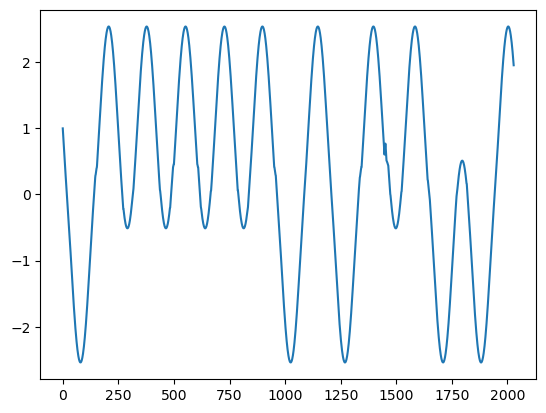

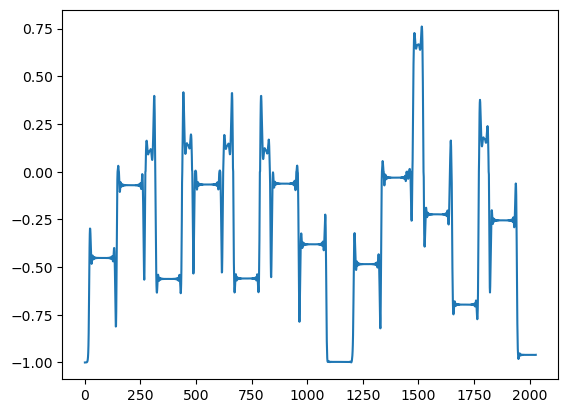

In [5]:
oscillator_positions = [trajectory[i].positions for i in range(len(trajectory))]
rev_oscillator_positions = [rev_traj[i].positions for i in range(len(rev_traj))]

Sz_lst = [sz_from_coeff(trajectory[i].coefficients) for i in range(len(trajectory))]

from matplotlib import pyplot as plt

print(Sz_lst[148])
plt.figure()
plt.plot(range(len(trajectory)), oscillator_positions)
# plt.plot(range(len(rev_traj)), rev_oscillator_positions)
plt.show()

plt.figure()
plt.plot(range(len(trajectory)), Sz_lst)
plt.show()

